# Automatically generating object masks with SAM

Since SAM can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image. This method was used to generate the dataset SA-1B.

The class `SamAutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [2]:
using_colab = True

In [ ]:
import sys
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

## Set-up

In [4]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2


In [123]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def show_image(path, figsize=(5, 5)) -> None:
    """shows image and returns back the array"""
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    return image

def show_mask_over_image(masks, image, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    show_anns(masks)
    plt.axis('off')
    plt.show()

In [12]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# mask_generator = SamAutomaticMaskGenerator(sam)

In [367]:
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    # crop_n_layers=1,
    # crop_n_points_downscale_factor=2,
    # min_mask_region_area=100
)

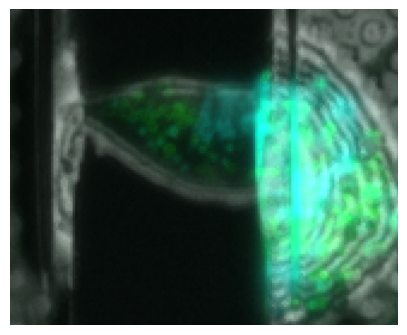

In [237]:
image_flm_coloured = show_image('/content/flm_coloured_2.png')

In [282]:
masks_flm_coloured = mask_generator.generate(image_flm_coloured)

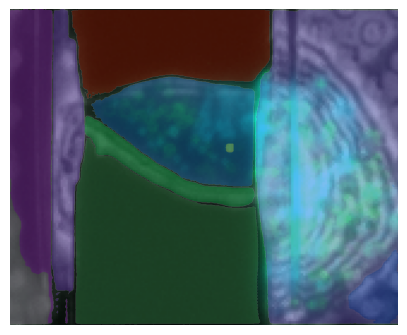

In [283]:
show_mask_over_image(masks_flm_coloured, image_flm_coloured)

In [284]:
# arrange the masks by the decreasing area
masks_flm_coloured = sorted(masks_flm_coloured, key=lambda x: -x['area'])

In [285]:
len(masks_flm_coloured)

10

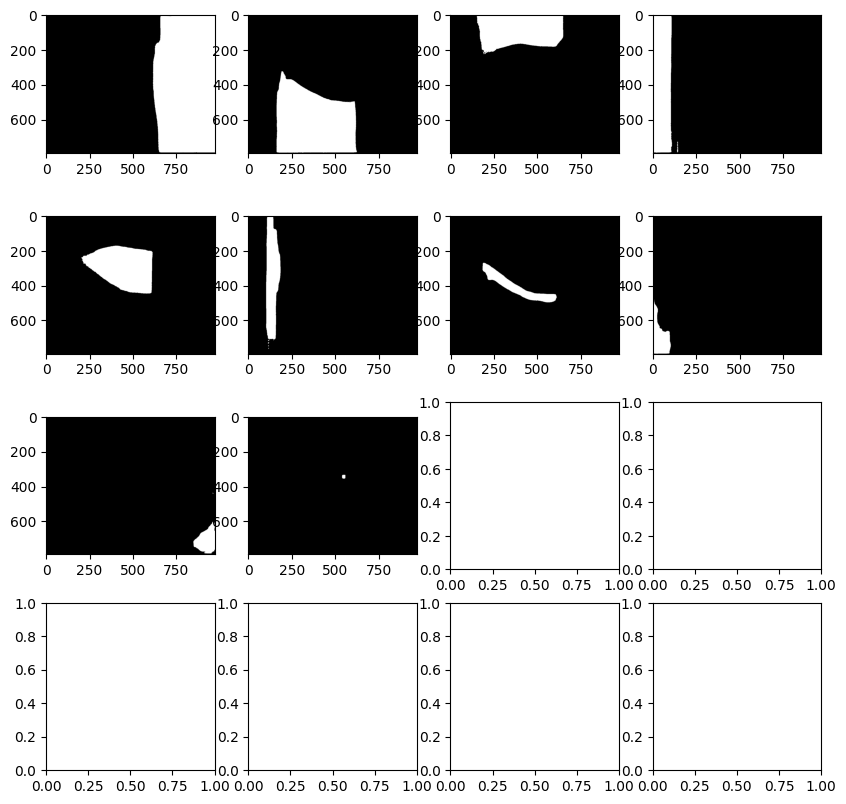

In [319]:
# total 13 masks 4 x 3 grid
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(len(masks_flm_coloured)):
    row = i // 4
    col = i % 4
    ax[row, col].imshow(masks_flm_coloured[i]['segmentation'], cmap='gray')

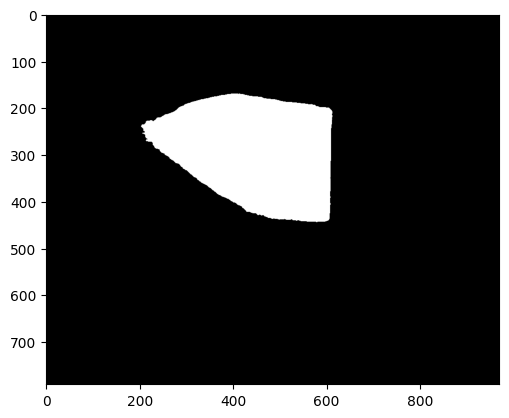

In [320]:
plt.imshow(masks_flm_coloured[4]['segmentation'], cmap='gray')

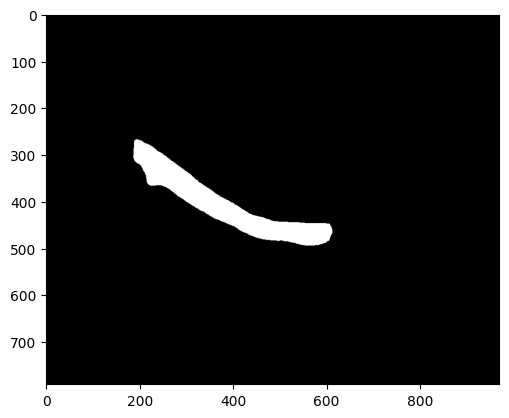

In [321]:
plt.imshow(masks_flm_coloured[6]['segmentation'], cmap='gray')

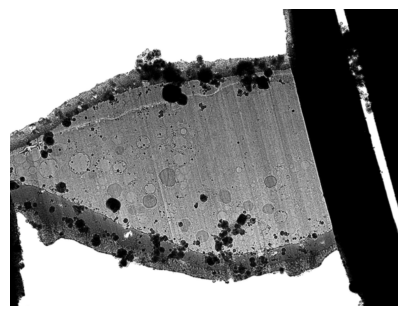

In [294]:
image_tem = show_image('/content/tem.png')

In [368]:
masks_tem = mask_generator.generate(image_tem)

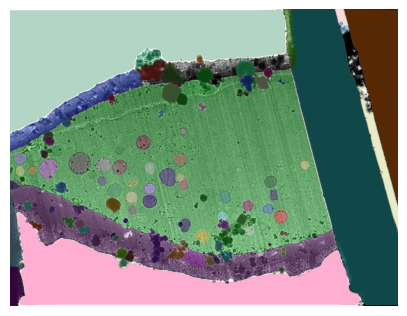

In [369]:
show_mask_over_image(masks_tem, image_tem)

In [370]:
# arrange the masks by the decreasing area
masks_tem = sorted(masks_tem, key=lambda x: -x['area'])

In [371]:
len(masks_tem)

109

IndexError: index 4 is out of bounds for axis 0 with size 4

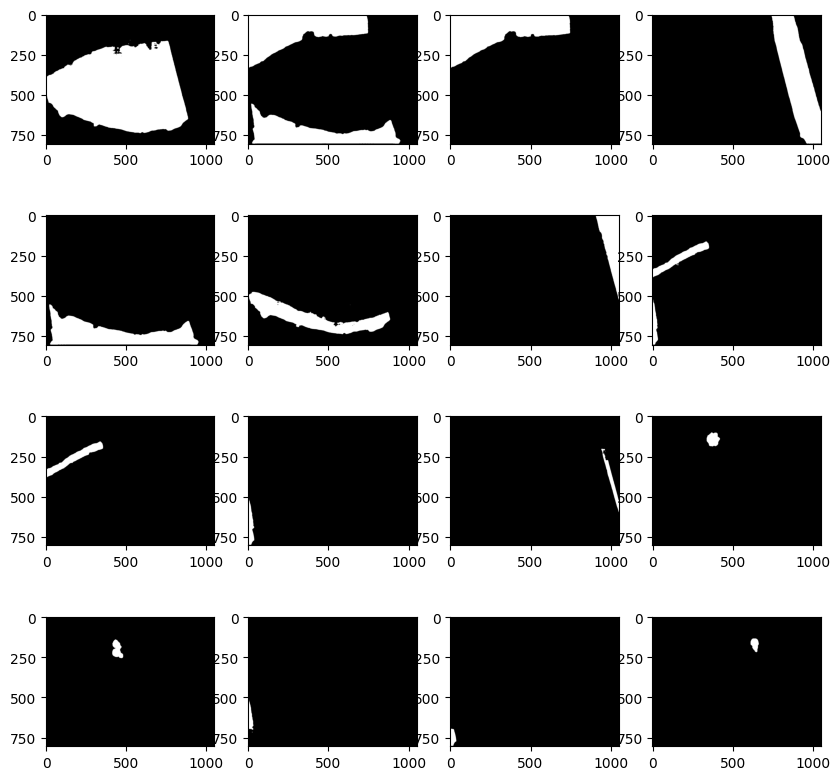

In [372]:
# total 13 masks 4 x 3 grid
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(len(masks_tem)):
    row = i // 4
    col = i % 4
    ax[row, col].imshow(masks_tem[i]['segmentation'], cmap='gray')

In [327]:

from pathlib import Path

if Path.cwd().name != "LightGlue":
    !git clone --quiet https://github.com/cvg/LightGlue/
    %cd LightGlue
    !pip install --progress-bar off --quiet -e .

from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd
from lightglue import viz2d
import torch

torch.set_grad_enabled(False)

/content/LightGlue
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for lightglue (pyproject.toml) ... done


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [433]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
# matcher = LightGlue(features="superpoint").eval().to(device)
matcher = LightGlue(
    features="superpoint",
    depth_confidence=-1,   # disable early stopping
    width_confidence=-1,    # disable pruning
    filter_threshold=0.1,
).eval().to(device)

In [434]:
def create_tensor_from_mask(mask):
    image = np.stack((mask,) * 3, axis=0)
    return torch.from_numpy(image).to(dtype=torch.float32)

In [460]:
image0 = create_tensor_from_mask(masks_flm_coloured[4]['segmentation'])
image1 = create_tensor_from_mask(masks_tem[0]['segmentation'])

In [461]:
feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]


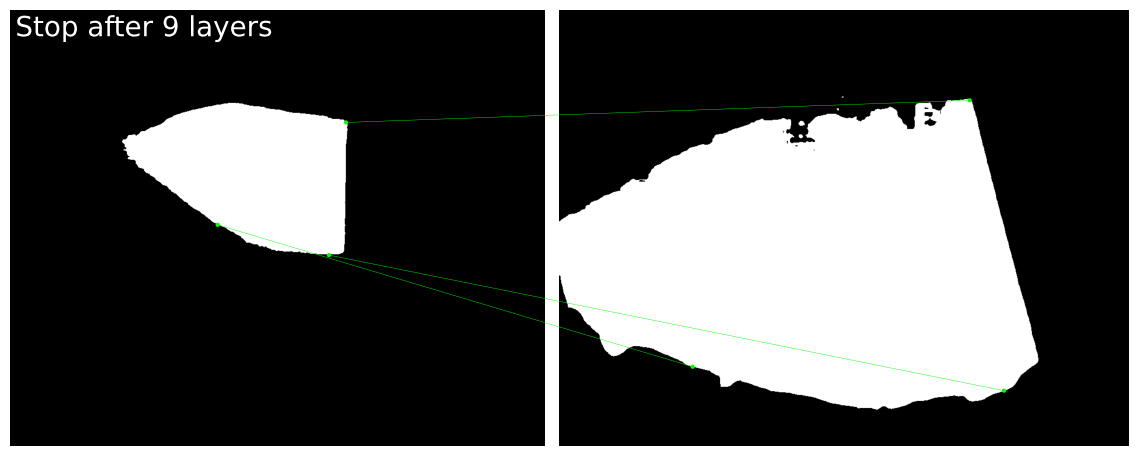

In [462]:
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.3)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

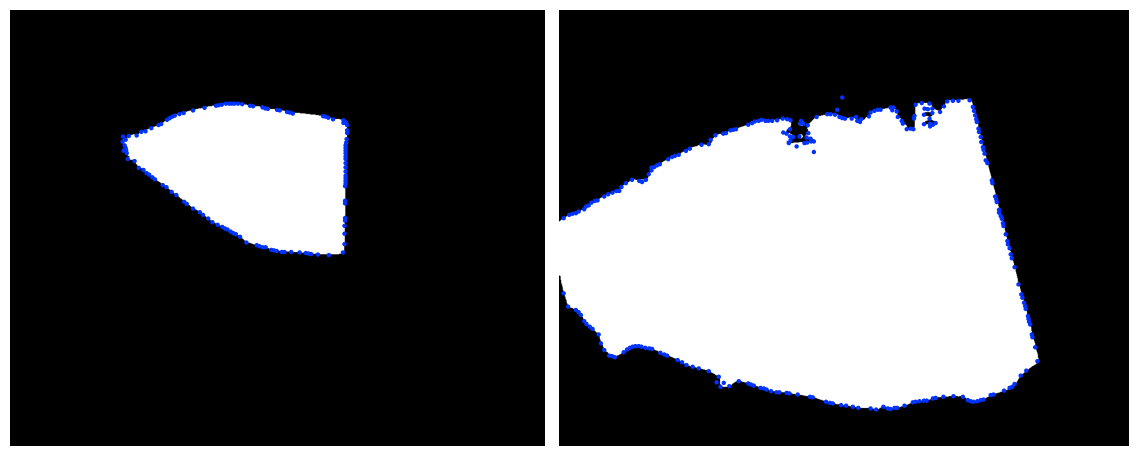

In [443]:
kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

In [388]:
def match_sift_keypoints(tem_img, flm_img):

    sift = cv2.SIFT.create(
        nfeatures=0, # 0 = detect all,
        nOctaveLayers=3, # layers per octave in the pyramid
        contrastThreshold=0.04, # lower = more keypoints detected
        edgeThreshold=10, # higher = mroe keypoints detected
        sigma=1.6, # blur for the first octave
    )
    keypoints_flm, descriptors_flm = sift.detectAndCompute(flm_img, None)
    keypoints_tem, descriptors_tem = sift.detectAndCompute(tem_img, None)

    # img_keypoints = cv2.drawKeypoints(flm_img, keypoints_flm, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    # cv2.imwrite(out_dir / 'keypoints_flm.png', img_keypoints)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptors_flm, descriptors_tem, k=2)

    # Lowe's ratio test to filter out the bad matches
    good_matches = []
    for m, n in matches:
        if m.distance < 0.85 * n.distance:
            good_matches.append(m)

    img_matches = cv2.drawMatches(flm_img, keypoints_flm, tem_img, keypoints_tem, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return img_matches

In [453]:
img1 = masks_flm_coloured[6]['segmentation'].astype(np.uint8)
img2 = masks_tem[5]['segmentation'].astype(np.uint8)

In [454]:
img1[np.where(img1 == 1)] = 255
img2[np.where(img2 == 1)] = 255

In [455]:
img_matches = match_sift_keypoints(img2, img1)

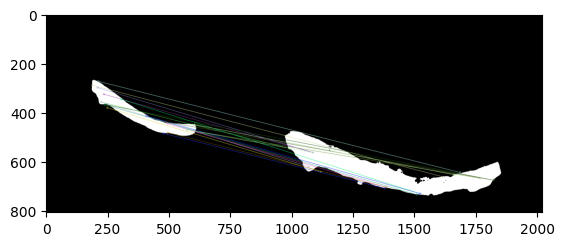

In [456]:
plt.imshow(img_matches)